<a href="https://colab.research.google.com/github/sabinereis28/projeto-gestao-logexpress-2026/blob/main/03-analise-de-dados/analise_entregas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o arquivo diretamente do GitHub (link raw correto)
url = 'https://raw.githubusercontent.com/sabinereis28/projeto-gestao-logexpress-2026/main/03-analise-de-dados/dados_entregas.csv'
df = pd.read_csv(url)

# 2. Tratamento ETL: remover linhas com dados nulos
df.dropna(subset=['dias_decorridos'], inplace=True)

print("--- Dados Tratados com Sucesso ---")
print(df.head())

--- Dados Tratados com Sucesso ---
   id_pedido  distancia_km  prazo_dias  dias_decorridos             status  \
0        101            45           2              2.0  Entregue no Prazo   
1        102           120           4              5.0           Atrasado   
2        103            15           1              1.0  Entregue no Prazo   
3        104           300           6              8.0           Atrasado   
4        105            80           3              3.0  Entregue no Prazo   

   valor_frete  custo_combustivel  
0         85.5               30.0  
1        210.0               90.0  
2         45.0               10.0  
3        450.0              280.0  
4        130.0               50.0  


In [7]:
# --- 2.1 Métricas (KPIs) ---
faturamento_total = df['valor_frete'].sum()
entregas_no_prazo = df[df['status'] == 'Entregue no Prazo'].shape[0]
taxa_sucesso = (entregas_no_prazo / df.shape[0]) * 100
custo_medio_frete = df['valor_frete'].mean()

print("=== INDICADORES (KPIs) ===")
print(f"Faturamento Total: R$ {faturamento_total:,.2f}")
print(f"Taxa de Sucesso (No Prazo): {taxa_sucesso:.1f}%")
print(f"Custo Médio por Frete: R$ {custo_medio_frete:,.2f}\n")

# --- 2.2 Estatística Descritiva ---
media_atraso = df['dias_decorridos'].mean()
desvio_padrao_atraso = df['dias_decorridos'].std()
correlacao, p_valor = stats.pearsonr(df['distancia_km'], df['custo_combustivel'])

print("=== ESTATÍSTICA DESCRITIVA ===")
print(f"Média de Dias Decorridos: {media_atraso:.2f} dias")
print(f"Desvio Padrão dos Atrasos: {desvio_padrao_atraso:.2f}")
print(f"Correlação Distância x Custo de Combustível: {correlacao:.2f}")

=== INDICADORES (KPIs) ===
Faturamento Total: R$ 3,510.50
Taxa de Sucesso (No Prazo): 54.5%
Custo Médio por Frete: R$ 319.14

=== ESTATÍSTICA DESCRITIVA ===
Média de Dias Decorridos: 5.00 dias
Desvio Padrão dos Atrasos: 3.38
Correlação Distância x Custo de Combustível: 0.93


/tmp/ipykernel_2048/2013717396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', ax=axes[0], palette='Set2')


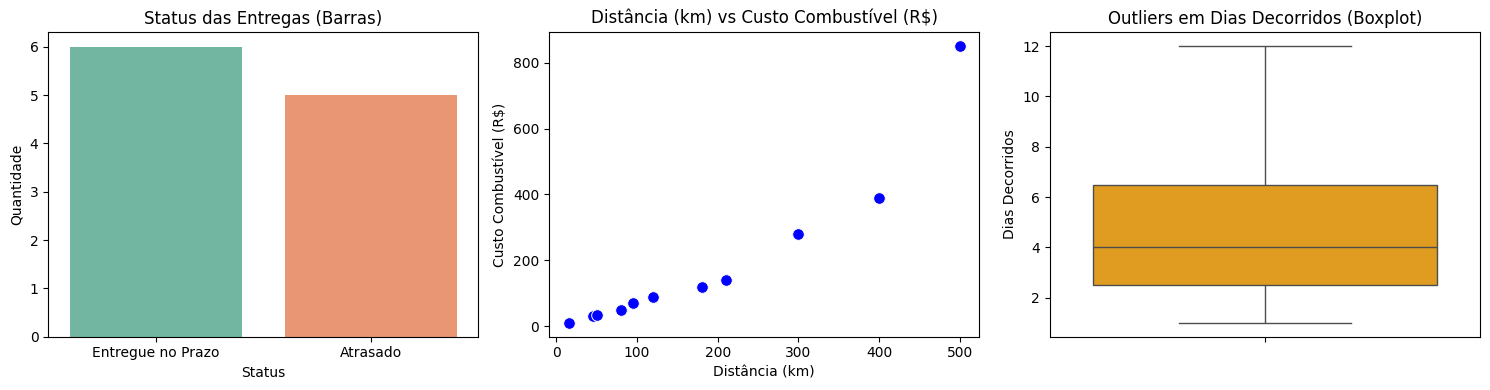

In [8]:
# --- 2.3 Visualização de Dados (Gráficos) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Gráfico de Barras: Status das Entregas
sns.countplot(data=df, x='status', ax=axes[0], palette='Set2')
axes[0].set_title('Status das Entregas (Barras)')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Quantidade')

# 2. Gráfico de Dispersão: Distância vs Custo de Combustível
sns.scatterplot(data=df, x='distancia_km', y='custo_combustivel', ax=axes[1], color='blue', s=70)
axes[1].set_title('Distância (km) vs Custo Combustível (R$)')
axes[1].set_xlabel('Distância (km)')
axes[1].set_ylabel('Custo Combustível (R$)')

# 3. Boxplot: Identificação de Outliers nos Dias Decorridos
sns.boxplot(data=df, y='dias_decorridos', ax=axes[2], color='orange')
axes[2].set_title('Outliers em Dias Decorridos (Boxplot)')
axes[2].set_ylabel('Dias Decorridos')

plt.tight_layout()
plt.show()